/Users/tomo/Documents/Numerical/Woodhouse2013-ERA5/jupyter/Tokachi1962 (stuts)
https://chatgpt.com/share/6991b92a-a108-8008-8545-7aea8d6880fe
ERA5を用いた十勝岳1962噴煙解析。

/var/folders/xd/msh5srmj40702mpq6nhmmpjw0000gn/T/ipykernel_9695/2798041572.py:143: RuntimeWarning: invalid value encountered in sqrt
  def r(z, y1, y2, y3, Q): return np.sqrt(y1 / rho(z, y1, y2, y3, Q) / (y2 / y1))


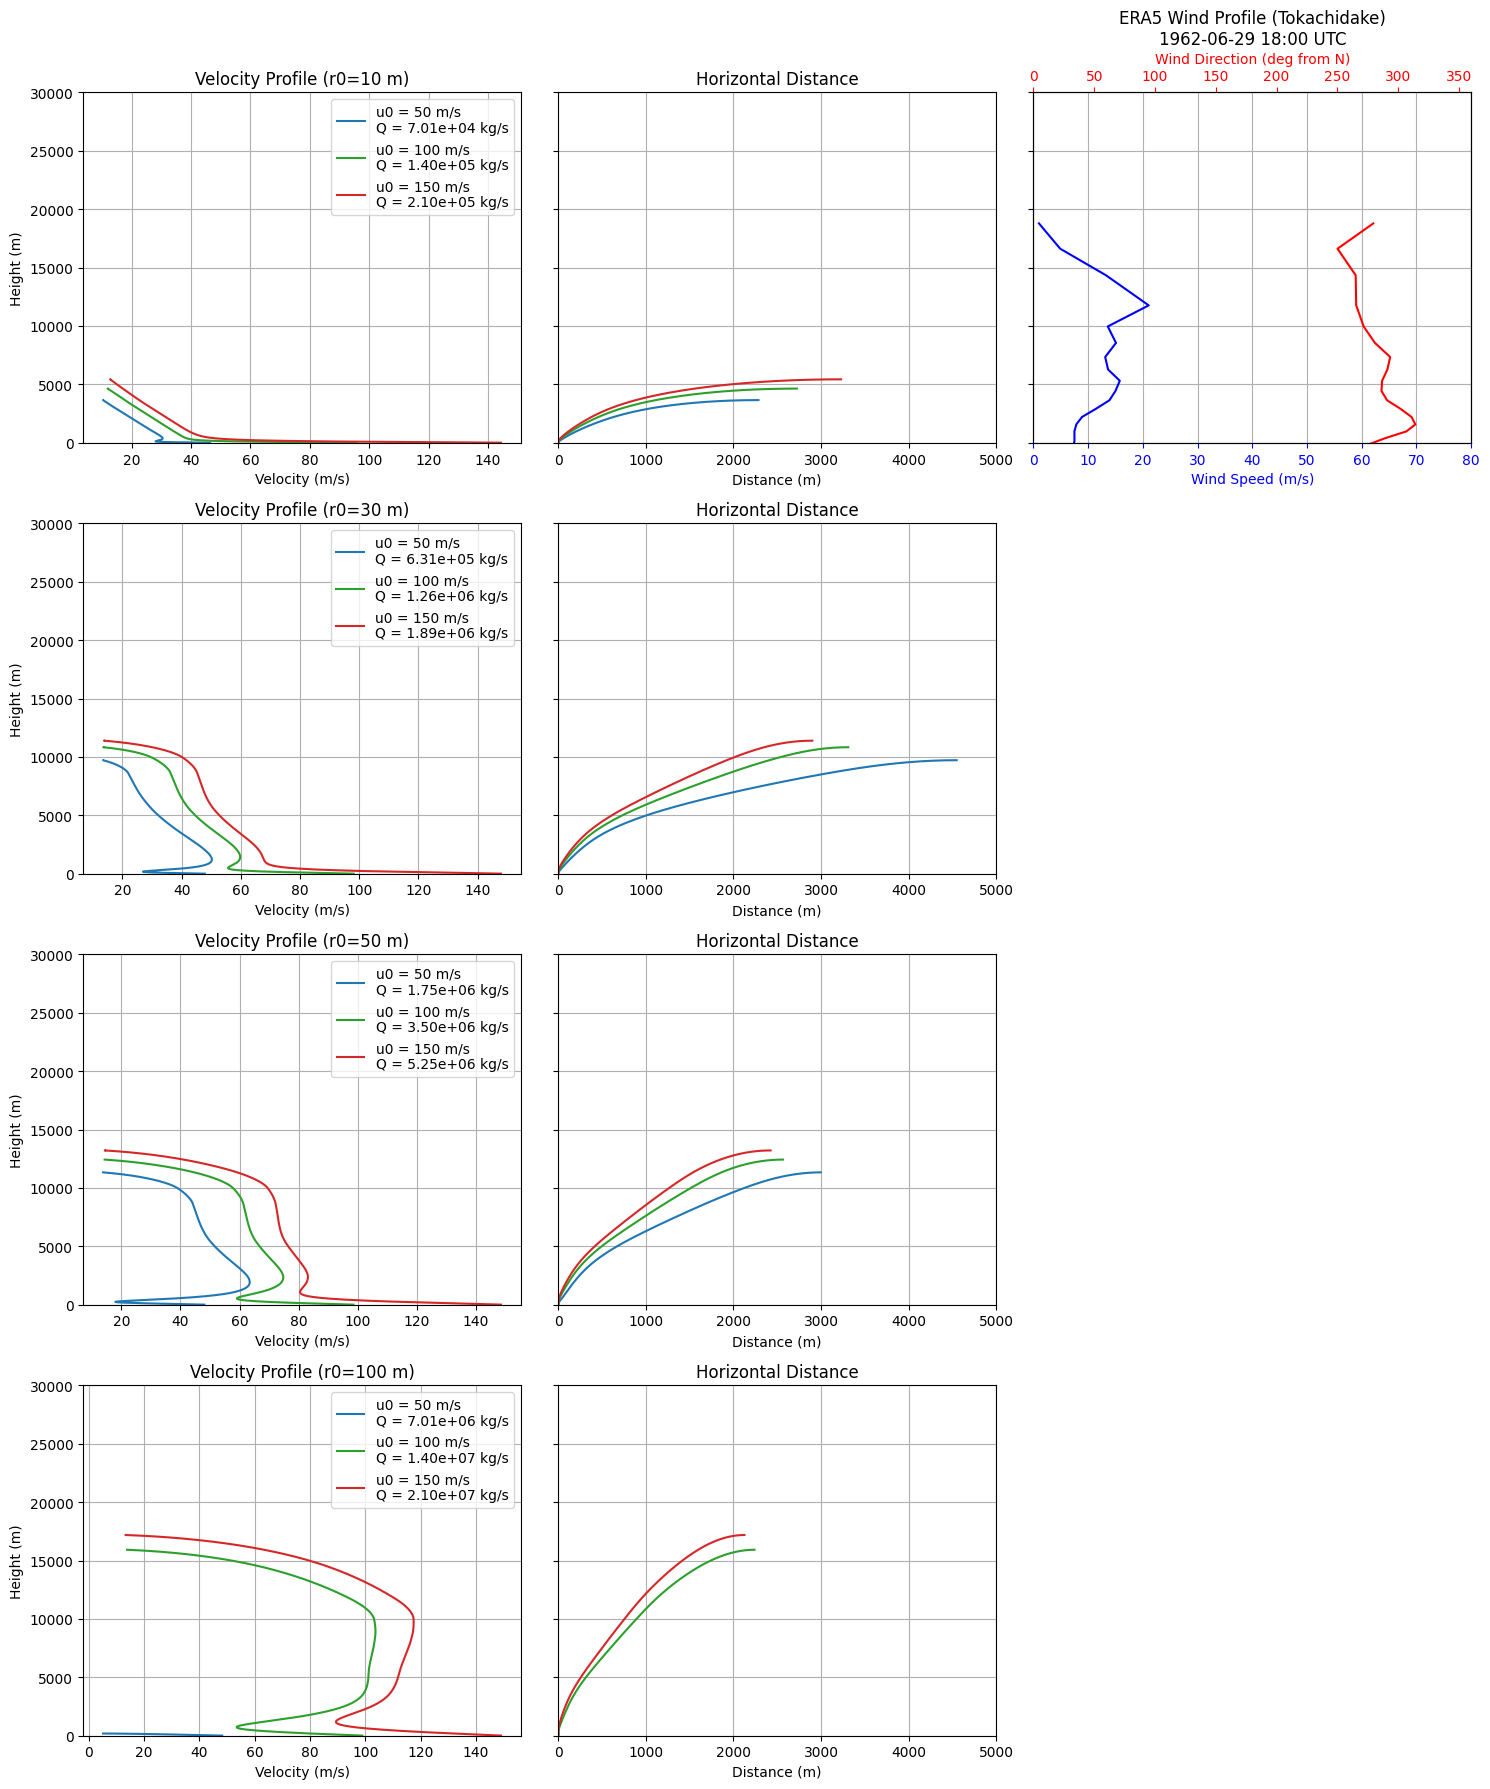

In [3]:
import xarray as xr
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from datetime import datetime
import os

# =========================
# 出力フォルダ
# =========================
os.makedirs("csv", exist_ok=True)
os.makedirs("png", exist_ok=True)

# =========================
# 設定：十勝岳 1962 / 18:00 UTC
# =========================
target_date = "1962-06-29"          # UTC
date_str = "19620629"
target_time = "18:00"
hour_str = "18"

# Tokachidake (代表値)
lat0, lon0 = 43.418, 142.686
height = 2077.0  # [m] まずは山頂（噴出口標高にしたければここを変更）

# ERA5 pressure-levels 取得ファイル名
ncfile = f"era5_tokachi_{date_str}_{hour_str}UTC_pl.nc"

# =========================
# 1) ERA5をダウンロード（初回だけ）
# =========================
if not os.path.exists(ncfile):
    import cdsapi
    c = cdsapi.Client()

    c.retrieve(
        "reanalysis-era5-pressure-levels",
        {
            "product_type": "reanalysis",
            "variable": [
                "u_component_of_wind",
                "v_component_of_wind",
                "temperature",
                "geopotential",
            ],
            "pressure_level": [str(p) for p in
                               [1000,975,950,925,900,875,850,825,800,775,750,725,700,
                                650,600,550,500,450,400,350,300,250,200,150,100,70,50]],
            "year": "1962",
            "month": "06",
            "day": "29",
            "time": ["18:00"],
            # [北, 西, 南, 東]
            "area": [44.5, 141.5, 42.5, 143.5],
            "format": "netcdf",
        },
        ncfile
    )

# =========================
# 2) ERA5を読み込み → 風プロファイル作成
# =========================
ds = xr.open_dataset(ncfile)

# ERA5: latitudeは北→南に並ぶことが多いので method="nearest" でOK
pt = ds.sel(latitude=lat0, longitude=lon0, method="nearest")

pt = pt.isel(valid_time=0, drop=True) if "valid_time" in pt.dims else pt
pt = pt.isel(number=0, drop=True)     if "number"     in pt.dims else pt
pt = pt.isel(expver=0, drop=True)     if "expver"     in pt.dims else pt
pt = pt.squeeze(drop=True)

plev_name = "pressure_level" if "pressure_level" in pt.coords else "level"
pressure = pt[plev_name].values.astype(float)
u = pt["u"].values
v = pt["v"].values
T = pt["t"].values  # [K]

# geopotential z [m^2/s^2] -> height [m]
g0 = 9.80665
altitude = pt["z"].values / g0  # [m]

wind_speed = np.sqrt(u**2 + v**2)
wind_dir = (np.degrees(np.arctan2(-u, -v)) + 360) % 360

df_gfs = pd.DataFrame({
    "Pressure_hPa": pressure,
    "Altitude_m": altitude,
    "WindSpeed_mps": wind_speed,
    "WindDirection_deg": wind_dir,
    "Temperature_K": T
}).sort_values("Altitude_m")

# 火口基準（z=0 at vent altitude）
df_gfs["z_rel_m"] = df_gfs["Altitude_m"] - height
df_gfs = df_gfs.sort_values("z_rel_m").drop_duplicates(subset="z_rel_m")

df_gfs.to_csv(f"csv/era5_tokachi_{date_str}_{hour_str}UTC.csv", index=False)

# =========================
# 3) v(z), tempa(z), p(z)
# =========================
v_interp = interp1d(df_gfs["z_rel_m"], df_gfs["WindSpeed_mps"],
                    bounds_error=False, fill_value="extrapolate")
T_interp = interp1d(df_gfs["z_rel_m"], df_gfs["Temperature_K"],
                    bounds_error=False, fill_value="extrapolate")
p_interp = interp1d(df_gfs["z_rel_m"], df_gfs["Pressure_hPa"] * 100.0,  # Pa
                    bounds_error=False, fill_value="extrapolate")

def v_of_z(z):   return v_interp(z)
def tempa(z):    return T_interp(z)
def p(z):        return p_interp(z)

# =========================
# 4) 噴煙モデル（あなたのまま）
# =========================
n0 = 0.03
T0 = 1273.0
theta0 = np.deg2rad(90.0)
ke, kw = 0.06, 0.2
pi, g = np.pi, 9.8
rga, rgv = 285.0, 462.0
cpm, cpa = 1000.0, 1000.0
rhol = 2.5e3

pa = p(0)
nv = n0

def rhoa(z): return p(z) / (rga * tempa(z))
def na(z, y1, Q): return 1.0 - Q / (pi * y1) if z > 0 else 0.0
def rg(z, y1, Q):
    na_ = na(z, y1, Q)
    return (na_ * rga + nv * (1 - na_) * rgv) / (na_ + nv * (1 - na_))
def cp(z, y1, Q): return na(z, y1, Q) * cpa + (1 - na(z, y1, Q)) * cpm
def temp(z, y1, y2, y3, Q): return 1.0 / cp(z, y1, Q) * (y3 / y1 - 0.5 * (y2 / y1)**2 - g * z)

def rho(z, y1, y2, y3, Q):
    na_ = na(z, y1, Q)
    return (((na_ + nv * (1 - na_)) * rg(z, y1, Q) * temp(z, y1, y2, y3, Q) / p(z))
            + (1 - na_) * (1 - nv) / rhol) ** (-1)

def r(z, y1, y2, y3, Q): return np.sqrt(y1 / rho(z, y1, y2, y3, Q) / (y2 / y1))

def uke(z, y1, y2, y4, Q):
    u_val = y2 / y1
    return ke * abs(u_val - v_of_z(z) * np.cos(y4)) + kw * abs(v_of_z(z) * np.sin(y4))

def f_vec(s, z, y, Q):
    y1, y2, y3, y4 = y
    r_ = r(z, y1, y2, y3, Q)
    rho_ = rho(z, y1, y2, y3, Q)
    rhoa_ = rhoa(z)
    uke_ = uke(z, y1, y2, y4, Q)
    f1 = 2 * uke_ * r_ * rhoa_
    f2 = r_**2 * (rhoa_ - rho_) * g * np.sin(y4) + v_of_z(z) * np.cos(y4) * f1
    f3 = (cpa * tempa(z) + g * z) * f1
    f4 = (r_**2 * (rhoa_ - rho_) * g * np.cos(y4) - v_of_z(z) * np.sin(y4) * f1) / y2
    return np.array([f1, f2, f3, f4])

r0_list = [10.0, 30.0, 50.0, 100.0]
u0_list = [50, 100, 150]
results_by_r0 = {}

for r0 in r0_list:
    results = {}
    for u0 in u0_list:
        rho0 = (nv * rgv * T0 / pa + (1 - nv) / rhol)**(-1)
        Q = rho0 * u0 * pi * r0**2
        y1 = Q / pi
        y2 = y1 * u0
        y3 = y1 * (cpm * T0 + u0**2 / 2)
        y4 = theta0
        y = np.array([y1, y2, y3, y4])

        s, z, x = 0.0, 0.0, 0.0
        ds_step = 10.0
        z_list, u_list, x_list = [], [], []

        for _ in range(10000):
            k1 = ds_step * f_vec(s, z, y, Q)
            k2 = ds_step * f_vec(s + ds_step/2, z + np.sin(y4)*ds_step/2, y + k1/2, Q)
            k3 = ds_step * f_vec(s + ds_step/2, z + np.sin(y4)*ds_step/2, y + k2/2, Q)
            k4 = ds_step * f_vec(s + ds_step, z + np.sin(y4)*ds_step, y + k3, Q)
            y_new = y + (k1 + 2*k2 + 2*k3 + k4) / 6

            z += ds_step * np.sin(y4)
            x += ds_step * np.cos(y4)
            y = y_new
            y4 = y[3]
            s += ds_step

            u_val = y[1] / y[0]
            z_list.append(z)
            u_list.append(u_val)
            x_list.append(x)

            if np.degrees(y4) <= 0 or z > 30000:
                break

        results[u0] = {"z": z_list, "u": u_list, "x": x_list, "Q": Q}

    results_by_r0[r0] = results

# =========================
# 5) プロット（あなたのまま、タイトルだけ変更）
# =========================
fig, axs = plt.subplots(nrows=4, ncols=3, figsize=(15, 18), sharey=True)
colors = ['tab:blue', 'tab:green', 'tab:red']

for i, r0 in enumerate(r0_list):
    for j, u0 in enumerate(u0_list):
        Q = results_by_r0[r0][u0]["Q"]
        label = f"u0 = {u0} m/s\nQ = {Q:.2e} kg/s"
        axs[i, 0].plot(results_by_r0[r0][u0]["u"], results_by_r0[r0][u0]["z"], label=label, color=colors[j])
        axs[i, 1].plot(results_by_r0[r0][u0]["x"], results_by_r0[r0][u0]["z"], color=colors[j])

    axs[i, 0].set_ylabel("Height (m)")
    axs[i, 0].set_xlabel("Velocity (m/s)")
    axs[i, 0].set_title(f"Velocity Profile (r0={int(r0)} m)")
    axs[i, 0].legend()
    axs[i, 0].grid(True)

    axs[i, 1].set_title("Horizontal Distance")
    axs[i, 1].set_xlabel("Distance (m)")
    axs[i, 1].set_xlim(0, 5000)
    axs[i, 1].grid(True)

# 風速・風向プロファイル（最上段のみ）
ax3 = axs[0, 2]
ax3_tw = ax3.twiny()
ax3.plot(df_gfs["WindSpeed_mps"], df_gfs["z_rel_m"], 'b')
ax3.set_xlabel("Wind Speed (m/s)", color='b')
ax3.tick_params(axis='x', colors='b')
ax3.set_xlim(0, 80)
ax3.set_title(f"ERA5 Wind Profile (Tokachidake)\n{target_date} {target_time} UTC")
ax3.grid(True)

ax3_tw.plot(df_gfs["WindDirection_deg"], df_gfs["z_rel_m"], 'r')
ax3_tw.set_xlabel("Wind Direction (deg from N)", color='r')
ax3_tw.tick_params(axis='x', colors='r')
ax3_tw.set_xlim(0, 360)

# 空白領域
axs[1, 2].axis('off')
axs[2, 2].axis('off')
axs[3, 2].axis('off')

for i in range(4):
    for j in range(2):
        axs[i, j].set_ylim(0, 30000)

plt.tight_layout()
plt.savefig(f"png/plume_tokachi_{date_str}_{hour_str}UTC.png", dpi=300)
plt.show()


In [4]:
print(pt.dims)

FrozenMappingWarningOnValuesAccess({'pressure_level': 26})


In [5]:
print("u shape:", pt["u"].shape)
print("z shape:", pt["z"].shape)
print("pressure shape:", pt["pressure_level"].shape)

u shape: (26,)
z shape: (26,)
pressure shape: (26,)


/var/folders/xd/msh5srmj40702mpq6nhmmpjw0000gn/T/ipykernel_9695/1352873281.py:151: RuntimeWarning: invalid value encountered in sqrt
  def r(z, y1, y2, y3, Q): return np.sqrt(y1 / rho(z, y1, y2, y3, Q) / (y2 / y1))


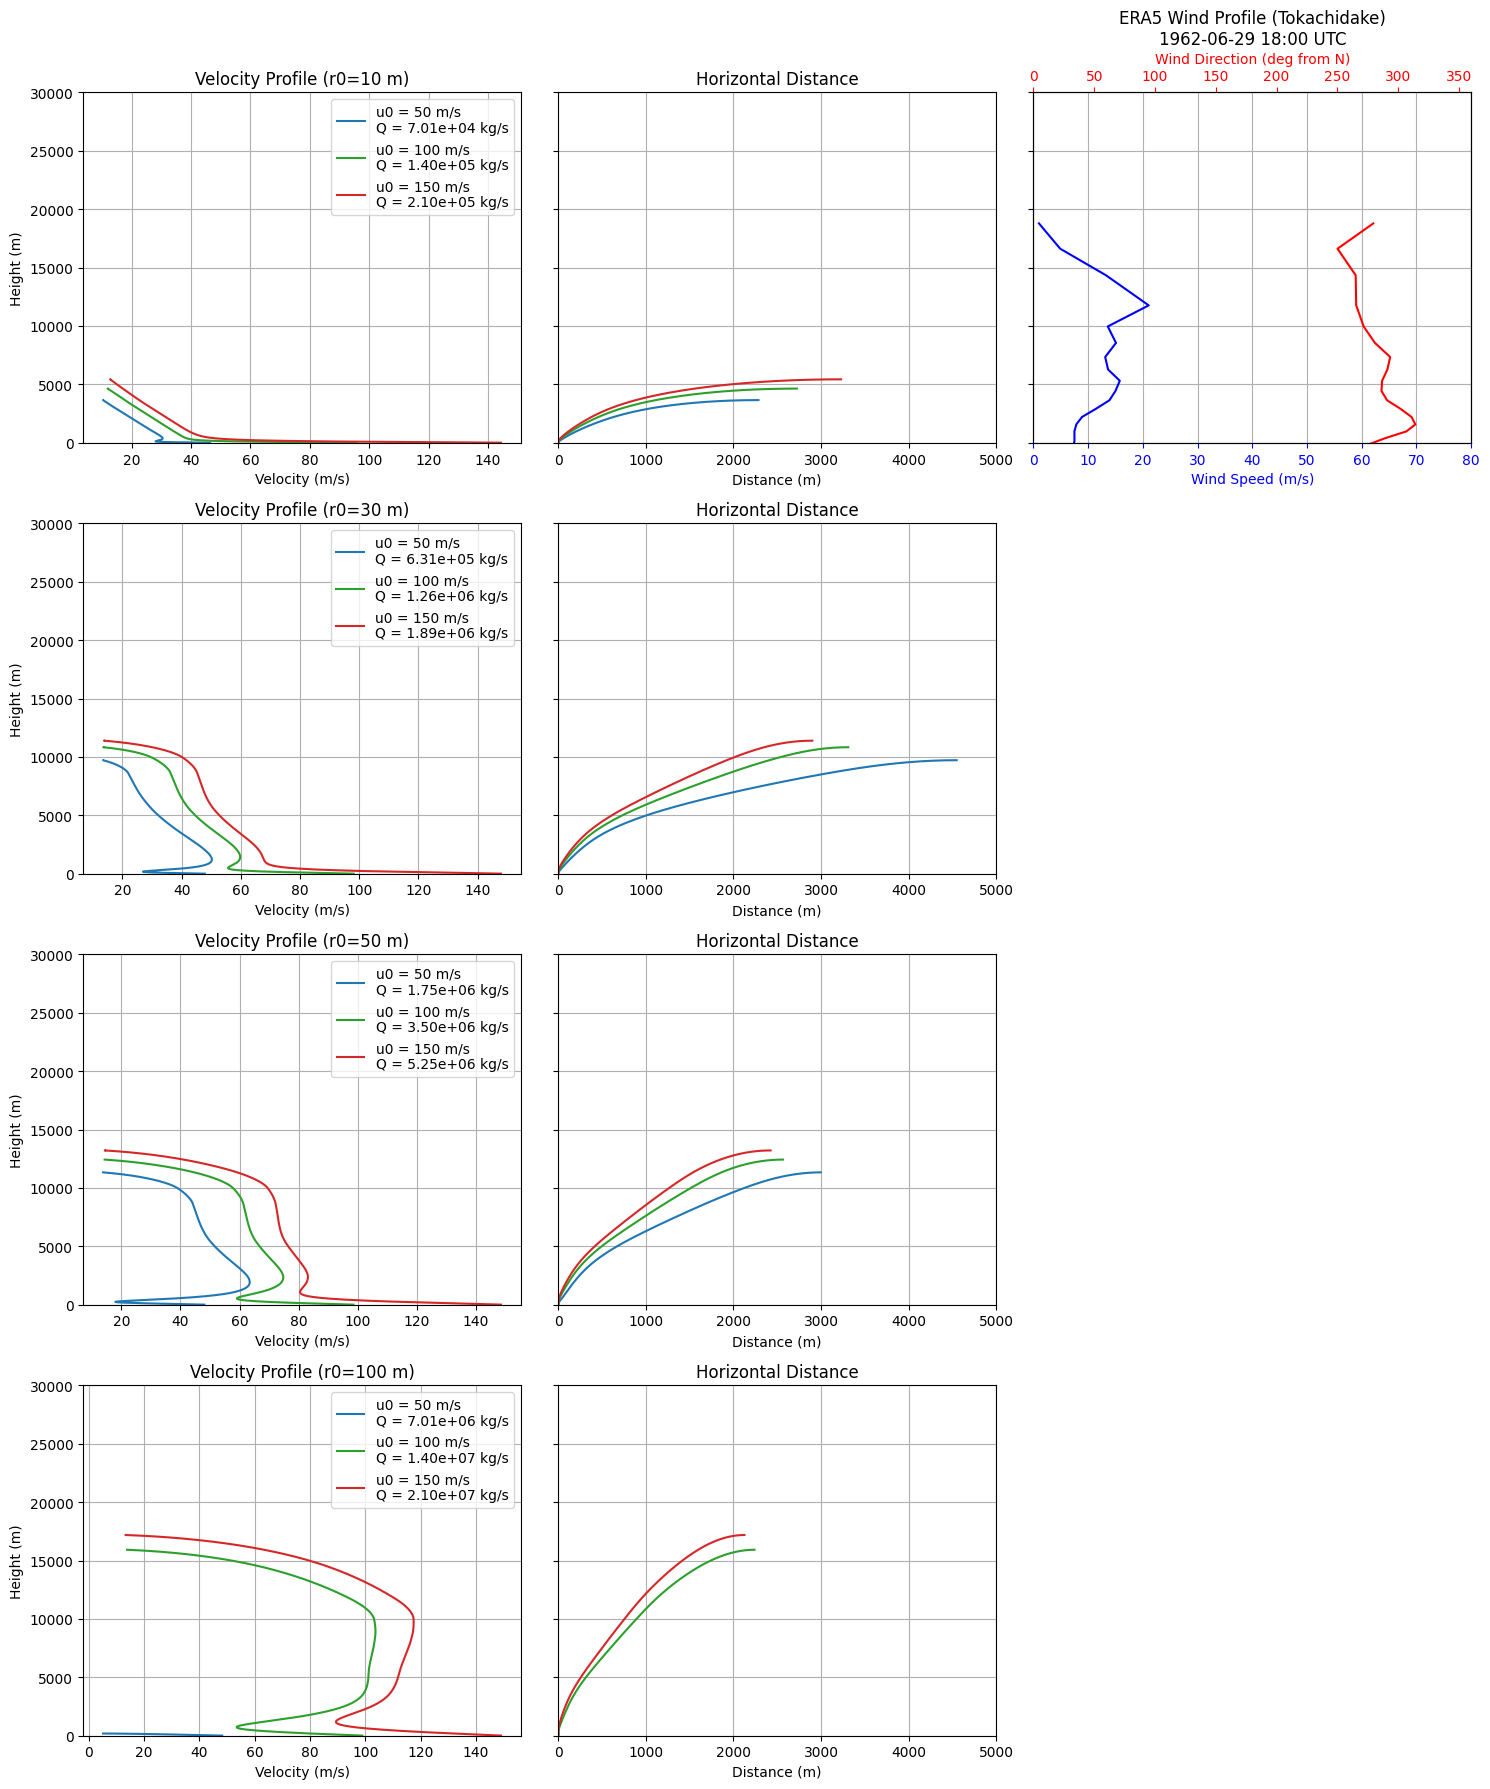

In [6]:
import xarray as xr
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from datetime import datetime
import os

# =========================
# 出力フォルダ
# =========================
os.makedirs("csv", exist_ok=True)
os.makedirs("png", exist_ok=True)

# =========================
# 設定：十勝岳 1962 / 18:00 UTC
# =========================
target_date = "1962-06-29"          # UTC
date_str = "19620629"
target_time = "18:00"
hour_str = "18"

# Tokachidake (代表値)
lat0, lon0 = 43.418, 142.686
height = 2077.0  # [m] まずは山頂（噴出口標高にしたければここを変更）

# ERA5 pressure-levels 取得ファイル名
ncfile = f"era5_tokachi_{date_str}_{hour_str}UTC_pl.nc"

# =========================
# 1) ERA5をダウンロード（初回だけ）
# =========================
if not os.path.exists(ncfile):
    import cdsapi
    c = cdsapi.Client()

    c.retrieve(
        "reanalysis-era5-pressure-levels",
        {
            "product_type": "reanalysis",
            "variable": [
                "u_component_of_wind",
                "v_component_of_wind",
                "temperature",
                "geopotential",
            ],
            "pressure_level": [str(p) for p in
                               [1000,975,950,925,900,875,850,825,800,775,750,725,700,
                                650,600,550,500,450,400,350,300,250,200,150,100,70,50]],
            "year": "1962",
            "month": "06",
            "day": "29",
            "time": ["18:00"],
            # [北, 西, 南, 東]
            "area": [44.5, 141.5, 42.5, 143.5],
            "format": "netcdf",
        },
        ncfile
    )

# =========================
# ERA5 読み込み（NetCDF）
# =========================
ncfile = f"era5_tokachi_{date_str}_{hour_str}UTC_pl.nc"
ds = xr.open_dataset(ncfile)

# 最近傍格子点
pt = ds.sel(latitude=lat0, longitude=lon0, method="nearest")

# 余計な次元が残る場合に備えて潰す（今回のファイル形式差にも強い）
for d in ["valid_time", "time", "expver", "number"]:
    if d in pt.dims:
        pt = pt.isel({d: 0}, drop=True)

pt = pt.squeeze(drop=True)

# pressure-level 座標名の揺れに対応
plev_name = "pressure_level" if "pressure_level" in pt.coords else "level"

# 必ず 1次元配列にする（pandas対策として堅牢）
pressure = np.ravel(pt[plev_name].values).astype(float)   # [hPa]
u = np.ravel(pt["u"].values)
v = np.ravel(pt["v"].values)
T = np.ravel(pt["t"].values)                              # [K]

g0 = 9.80665
altitude = np.ravel(pt["z"].values) / g0                  # geopotential -> [m]

# 風速・風向
wind_speed = np.sqrt(u**2 + v**2)
wind_dir = (np.degrees(np.arctan2(-u, -v)) + 360) % 360

# DataFrame
df_gfs = pd.DataFrame({
    "Pressure_hPa": pressure,
    "Altitude_m": altitude,
    "WindSpeed_mps": wind_speed,
    "WindDirection_deg": wind_dir,
    "Temperature_K": T
}).sort_values("Altitude_m")

# 保存（確認用）
df_gfs.to_csv(f"csv/era5_tokachi_{date_str}_{hour_str}UTC.csv", index=False)

# 火口基準（z=0 at vent altitude）
df_gfs["z_rel_m"] = df_gfs["Altitude_m"] - height
df_gfs = df_gfs.sort_values("z_rel_m").drop_duplicates(subset="z_rel_m")

# =========================
# 3) v(z), tempa(z), p(z)
# =========================
v_interp = interp1d(df_gfs["z_rel_m"], df_gfs["WindSpeed_mps"],
                    bounds_error=False, fill_value="extrapolate")
T_interp = interp1d(df_gfs["z_rel_m"], df_gfs["Temperature_K"],
                    bounds_error=False, fill_value="extrapolate")
p_interp = interp1d(df_gfs["z_rel_m"], df_gfs["Pressure_hPa"] * 100.0,  # Pa
                    bounds_error=False, fill_value="extrapolate")

def v_of_z(z):   return v_interp(z)
def tempa(z):    return T_interp(z)
def p(z):        return p_interp(z)

# =========================
# 4) 噴煙モデル（あなたのまま）
# =========================
n0 = 0.03
T0 = 1273.0
theta0 = np.deg2rad(90.0)
ke, kw = 0.06, 0.2
pi, g = np.pi, 9.8
rga, rgv = 285.0, 462.0
cpm, cpa = 1000.0, 1000.0
rhol = 2.5e3

pa = p(0)
nv = n0

def rhoa(z): return p(z) / (rga * tempa(z))
def na(z, y1, Q): return 1.0 - Q / (pi * y1) if z > 0 else 0.0
def rg(z, y1, Q):
    na_ = na(z, y1, Q)
    return (na_ * rga + nv * (1 - na_) * rgv) / (na_ + nv * (1 - na_))
def cp(z, y1, Q): return na(z, y1, Q) * cpa + (1 - na(z, y1, Q)) * cpm
def temp(z, y1, y2, y3, Q): return 1.0 / cp(z, y1, Q) * (y3 / y1 - 0.5 * (y2 / y1)**2 - g * z)

def rho(z, y1, y2, y3, Q):
    na_ = na(z, y1, Q)
    return (((na_ + nv * (1 - na_)) * rg(z, y1, Q) * temp(z, y1, y2, y3, Q) / p(z))
            + (1 - na_) * (1 - nv) / rhol) ** (-1)

def r(z, y1, y2, y3, Q): return np.sqrt(y1 / rho(z, y1, y2, y3, Q) / (y2 / y1))

def uke(z, y1, y2, y4, Q):
    u_val = y2 / y1
    return ke * abs(u_val - v_of_z(z) * np.cos(y4)) + kw * abs(v_of_z(z) * np.sin(y4))

def f_vec(s, z, y, Q):
    y1, y2, y3, y4 = y
    r_ = r(z, y1, y2, y3, Q)
    rho_ = rho(z, y1, y2, y3, Q)
    rhoa_ = rhoa(z)
    uke_ = uke(z, y1, y2, y4, Q)
    f1 = 2 * uke_ * r_ * rhoa_
    f2 = r_**2 * (rhoa_ - rho_) * g * np.sin(y4) + v_of_z(z) * np.cos(y4) * f1
    f3 = (cpa * tempa(z) + g * z) * f1
    f4 = (r_**2 * (rhoa_ - rho_) * g * np.cos(y4) - v_of_z(z) * np.sin(y4) * f1) / y2
    return np.array([f1, f2, f3, f4])

r0_list = [10.0, 30.0, 50.0, 100.0]
u0_list = [50, 100, 150]
results_by_r0 = {}

for r0 in r0_list:
    results = {}
    for u0 in u0_list:
        rho0 = (nv * rgv * T0 / pa + (1 - nv) / rhol)**(-1)
        Q = rho0 * u0 * pi * r0**2
        y1 = Q / pi
        y2 = y1 * u0
        y3 = y1 * (cpm * T0 + u0**2 / 2)
        y4 = theta0
        y = np.array([y1, y2, y3, y4])

        s, z, x = 0.0, 0.0, 0.0
        ds_step = 10.0
        z_list, u_list, x_list = [], [], []

        for _ in range(10000):
            k1 = ds_step * f_vec(s, z, y, Q)
            k2 = ds_step * f_vec(s + ds_step/2, z + np.sin(y4)*ds_step/2, y + k1/2, Q)
            k3 = ds_step * f_vec(s + ds_step/2, z + np.sin(y4)*ds_step/2, y + k2/2, Q)
            k4 = ds_step * f_vec(s + ds_step, z + np.sin(y4)*ds_step, y + k3, Q)
            y_new = y + (k1 + 2*k2 + 2*k3 + k4) / 6

            z += ds_step * np.sin(y4)
            x += ds_step * np.cos(y4)
            y = y_new
            y4 = y[3]
            s += ds_step

            u_val = y[1] / y[0]
            z_list.append(z)
            u_list.append(u_val)
            x_list.append(x)

            if np.degrees(y4) <= 0 or z > 30000:
                break

        results[u0] = {"z": z_list, "u": u_list, "x": x_list, "Q": Q}

    results_by_r0[r0] = results

# =========================
# 5) プロット（あなたのまま、タイトルだけ変更）
# =========================
fig, axs = plt.subplots(nrows=4, ncols=3, figsize=(15, 18), sharey=True)
colors = ['tab:blue', 'tab:green', 'tab:red']

for i, r0 in enumerate(r0_list):
    for j, u0 in enumerate(u0_list):
        Q = results_by_r0[r0][u0]["Q"]
        label = f"u0 = {u0} m/s\nQ = {Q:.2e} kg/s"
        axs[i, 0].plot(results_by_r0[r0][u0]["u"], results_by_r0[r0][u0]["z"], label=label, color=colors[j])
        axs[i, 1].plot(results_by_r0[r0][u0]["x"], results_by_r0[r0][u0]["z"], color=colors[j])

    axs[i, 0].set_ylabel("Height (m)")
    axs[i, 0].set_xlabel("Velocity (m/s)")
    axs[i, 0].set_title(f"Velocity Profile (r0={int(r0)} m)")
    axs[i, 0].legend()
    axs[i, 0].grid(True)

    axs[i, 1].set_title("Horizontal Distance")
    axs[i, 1].set_xlabel("Distance (m)")
    axs[i, 1].set_xlim(0, 5000)
    axs[i, 1].grid(True)

# 風速・風向プロファイル（最上段のみ）
ax3 = axs[0, 2]
ax3_tw = ax3.twiny()
ax3.plot(df_gfs["WindSpeed_mps"], df_gfs["z_rel_m"], 'b')
ax3.set_xlabel("Wind Speed (m/s)", color='b')
ax3.tick_params(axis='x', colors='b')
ax3.set_xlim(0, 80)
ax3.set_title(f"ERA5 Wind Profile (Tokachidake)\n{target_date} {target_time} UTC")
ax3.grid(True)

ax3_tw.plot(df_gfs["WindDirection_deg"], df_gfs["z_rel_m"], 'r')
ax3_tw.set_xlabel("Wind Direction (deg from N)", color='r')
ax3_tw.tick_params(axis='x', colors='r')
ax3_tw.set_xlim(0, 360)

# 空白領域
axs[1, 2].axis('off')
axs[2, 2].axis('off')
axs[3, 2].axis('off')

for i in range(4):
    for j in range(2):
        axs[i, j].set_ylim(0, 30000)

plt.tight_layout()
plt.savefig(f"png/plume_tokachi_{date_str}_{hour_str}UTC.png", dpi=300)
plt.show()


In [7]:
print(df_gfs[["Pressure_hPa","Altitude_m"]].head())
print("z_rel crosses 0?", (df_gfs["Altitude_m"]-height).min(), (df_gfs["Altitude_m"]-height).max())


   Pressure_hPa  Altitude_m
0        1000.0   89.907303
1         975.0  303.868103
2         950.0  522.298645
3         925.0  745.942322
4         900.0  974.935913
z_rel crosses 0? -1987.0927 18785.201


2026-02-15 23:00:48,943 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-02-15 23:00:48,945 INFO Request ID is 1e1f02ca-8cd5-4aee-84a1-edda0493a5d8
2026-02-15 23:00:49,353 INFO status has been updated to accepted
2026-02-15 23:00:59,170 INFO status has been updated to running
2026-02-15 23:01:12,597 INFO status has been updated to successful
/var/folders/xd/msh5srmj40702mpq6nhmmpjw0000gn/T/ipykernel_9695/66505747.py:209: RuntimeWarning: invalid value encountered in sqrt
  def r(z, y1, y2, y3, Q): return np.sqrt(y1 / rho(z, y1, y2, y3, Q) / (y2 / y1))


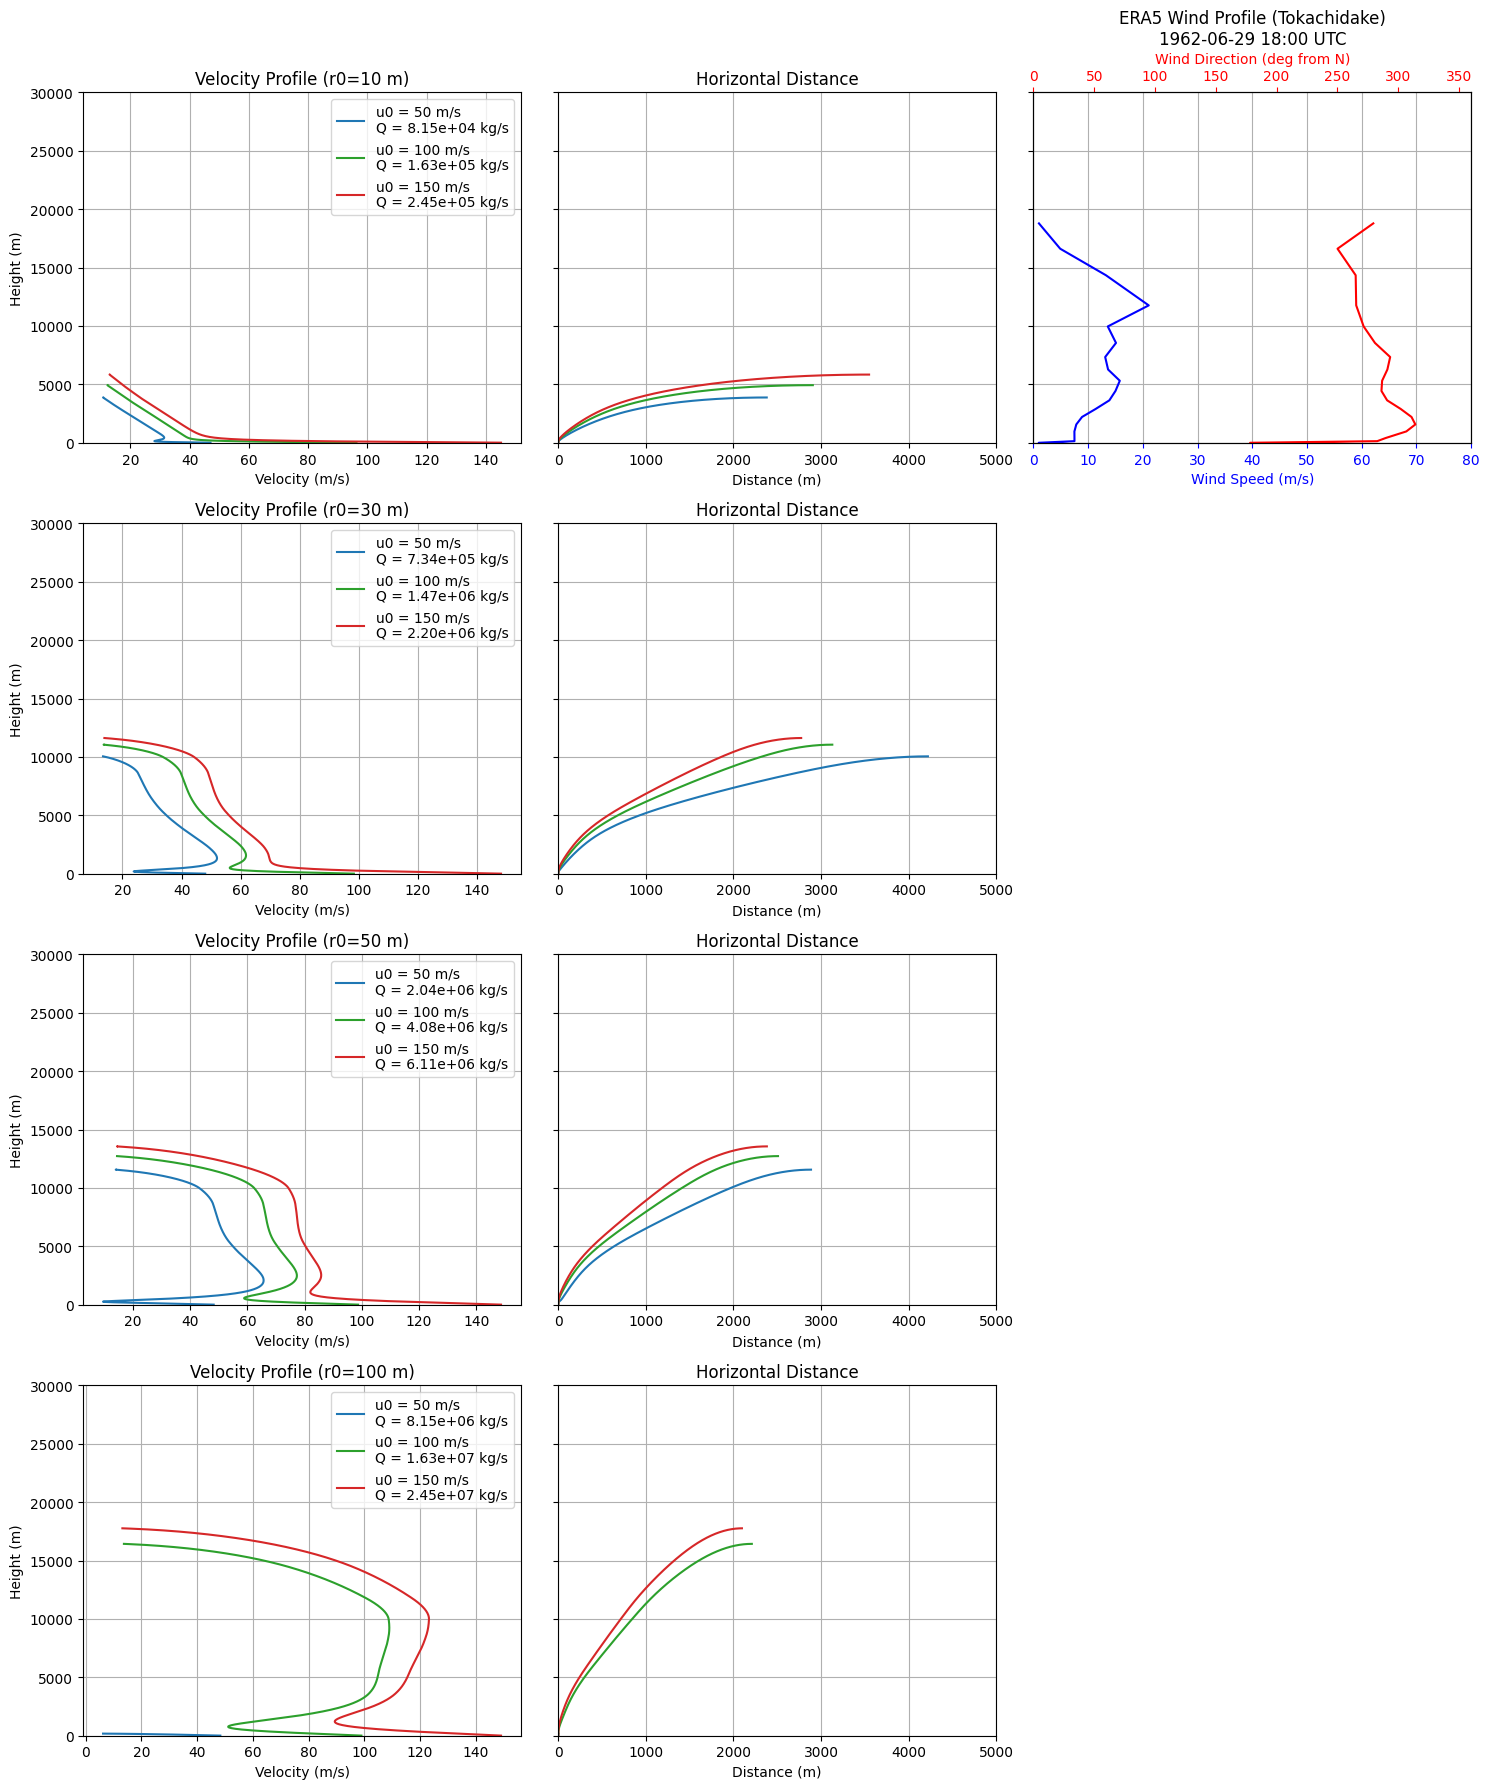

In [8]:
import xarray as xr
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from datetime import datetime
import os

# =========================
# 出力フォルダ
# =========================
os.makedirs("csv", exist_ok=True)
os.makedirs("png", exist_ok=True)

# =========================
# 設定：十勝岳 1962 / 18:00 UTC
# =========================
target_date = "1962-06-29"          # UTC
date_str = "19620629"
target_time = "18:00"
hour_str = "18"

# Tokachidake (代表値)
lat0, lon0 = 43.418, 142.686
height = 2077.0  # [m] まずは山頂（噴出口標高にしたければここを変更）

# ERA5 pressure-levels 取得ファイル名
ncfile = f"era5_tokachi_{date_str}_{hour_str}UTC_pl.nc"

# =========================
# ERA5 ファイル名
# =========================
ncfile_pl  = f"era5_tokachi_{date_str}_{hour_str}UTC_pl.nc"
ncfile_sfc = f"era5_tokachi_{date_str}_{hour_str}UTC_sfc.nc"

# =========================
# 1) ERA5 pressure-levels をダウンロード（初回だけ）
# =========================
if not os.path.exists(ncfile_pl):
    import cdsapi
    c = cdsapi.Client()
    c.retrieve(
        "reanalysis-era5-pressure-levels",
        {
            "product_type": "reanalysis",
            "variable": [
                "u_component_of_wind",
                "v_component_of_wind",
                "temperature",
                "geopotential",
            ],
            "pressure_level": [str(p) for p in
                               [1000,975,950,925,900,875,850,825,800,775,750,725,700,
                                650,600,550,500,450,400,350,300,250,200,150,100,70,50]],
            "year": "1962",
            "month": "06",
            "day": "29",
            "time": ["18:00"],
            "area": [44.5, 141.5, 42.5, 143.5],  # [N, W, S, E]
            "format": "netcdf",
        },
        ncfile_pl
    )

# =========================
# 1b) ERA5 single-levels をダウンロード（初回だけ）★火口点用
# =========================
if not os.path.exists(ncfile_sfc):
    import cdsapi
    c = cdsapi.Client()
    c.retrieve(
        "reanalysis-era5-single-levels",
        {
            "product_type": "reanalysis",
            "variable": [
                "10m_u_component_of_wind",
                "10m_v_component_of_wind",
                "2m_temperature",
                "surface_pressure",
            ],
            "year": "1962",
            "month": "06",
            "day": "29",
            "time": ["18:00"],
            "area": [44.5, 141.5, 42.5, 143.5],  # [N, W, S, E]
            "format": "netcdf",
        },
        ncfile_sfc
    )

# =========================
# 2) ERA5 pressure-levels を読み込み → 風プロファイル作成
# =========================
ds = xr.open_dataset(ncfile_pl)

pt = ds.sel(latitude=lat0, longitude=lon0, method="nearest")

# 余計な次元を潰す
for d in ["valid_time", "time", "expver", "number"]:
    if d in pt.dims:
        pt = pt.isel({d: 0}, drop=True)
pt = pt.squeeze(drop=True)

# 座標名の揺れに対応
plev_name = "pressure_level" if "pressure_level" in pt.coords else "level"

pressure = np.ravel(pt[plev_name].values).astype(float)  # [hPa]
u = np.ravel(pt["u"].values)
v = np.ravel(pt["v"].values)
T = np.ravel(pt["t"].values)                             # [K]
g0 = 9.80665
altitude = np.ravel(pt["z"].values) / g0                 # [m]

wind_speed = np.sqrt(u**2 + v**2)
wind_dir = (np.degrees(np.arctan2(-u, -v)) + 360) % 360

df_gfs = pd.DataFrame({
    "Pressure_hPa": pressure,
    "Altitude_m": altitude,
    "WindSpeed_mps": wind_speed,
    "WindDirection_deg": wind_dir,
    "Temperature_K": T
}).sort_values("Altitude_m")

# =========================
# 2b) ERA5 single-levels を読み込み → 火口（z_rel=0）点を追加
# =========================
ds_sfc = xr.open_dataset(ncfile_sfc)
pt_sfc = ds_sfc.sel(latitude=lat0, longitude=lon0, method="nearest")

for d in ["valid_time", "time", "expver", "number"]:
    if d in pt_sfc.dims:
        pt_sfc = pt_sfc.isel({d: 0}, drop=True)
pt_sfc = pt_sfc.squeeze(drop=True)

# 変数名（ERA5 single-levels 標準）
u10 = float(np.ravel(pt_sfc["u10"].values)[0])
v10 = float(np.ravel(pt_sfc["v10"].values)[0])
T2m = float(np.ravel(pt_sfc["t2m"].values)[0])                 # [K]
psfc_hpa = float(np.ravel(pt_sfc["sp"].values)[0]) / 100.0      # [Pa] -> [hPa]

ws_sfc = float(np.sqrt(u10**2 + v10**2))
wd_sfc = float((np.degrees(np.arctan2(-u10, -v10)) + 360) % 360)

df_surface = pd.DataFrame({
    "Pressure_hPa": [psfc_hpa],
    "Altitude_m": [height],           # ★ここが z_rel=0 になる
    "WindSpeed_mps": [ws_sfc],
    "WindDirection_deg": [wd_sfc],
    "Temperature_K": [T2m],
})

df_gfs = pd.concat([df_gfs, df_surface], ignore_index=True).sort_values("Altitude_m")

# 保存（確認用）
df_gfs.to_csv(f"csv/era5_tokachi_{date_str}_{hour_str}UTC.csv", index=False)

# =========================
# 火口基準（z=0 at vent altitude）
# =========================
df_gfs["z_rel_m"] = df_gfs["Altitude_m"] - height

# 念のため丸めて重複排除（float誤差対策）
df_gfs["z_rel_m_round"] = df_gfs["z_rel_m"].round(3)
df_gfs = df_gfs.sort_values("z_rel_m_round").drop_duplicates(subset="z_rel_m_round").drop(columns=["z_rel_m_round"])

# =========================
# 3) v(z), tempa(z), p(z)
# =========================
v_interp = interp1d(df_gfs["z_rel_m"], df_gfs["WindSpeed_mps"],
                    bounds_error=False, fill_value="extrapolate")
T_interp = interp1d(df_gfs["z_rel_m"], df_gfs["Temperature_K"],
                    bounds_error=False, fill_value="extrapolate")
p_interp = interp1d(df_gfs["z_rel_m"], df_gfs["Pressure_hPa"] * 100.0,  # Pa
                    bounds_error=False, fill_value="extrapolate")

def v_of_z(z):   return v_interp(z)
def tempa(z):    return T_interp(z)
def p(z):        return p_interp(z)

# =========================
# 4) 噴煙モデル（あなたのまま）
# =========================
n0 = 0.03
T0 = 1273.0
theta0 = np.deg2rad(90.0)
ke, kw = 0.06, 0.2
pi, g = np.pi, 9.8
rga, rgv = 285.0, 462.0
cpm, cpa = 1000.0, 1000.0
rhol = 2.5e3

pa = p(0)
nv = n0

def rhoa(z): return p(z) / (rga * tempa(z))
def na(z, y1, Q): return 1.0 - Q / (pi * y1) if z > 0 else 0.0
def rg(z, y1, Q):
    na_ = na(z, y1, Q)
    return (na_ * rga + nv * (1 - na_) * rgv) / (na_ + nv * (1 - na_))
def cp(z, y1, Q): return na(z, y1, Q) * cpa + (1 - na(z, y1, Q)) * cpm
def temp(z, y1, y2, y3, Q): return 1.0 / cp(z, y1, Q) * (y3 / y1 - 0.5 * (y2 / y1)**2 - g * z)

def rho(z, y1, y2, y3, Q):
    na_ = na(z, y1, Q)
    return (((na_ + nv * (1 - na_)) * rg(z, y1, Q) * temp(z, y1, y2, y3, Q) / p(z))
            + (1 - na_) * (1 - nv) / rhol) ** (-1)

def r(z, y1, y2, y3, Q): return np.sqrt(y1 / rho(z, y1, y2, y3, Q) / (y2 / y1))

def uke(z, y1, y2, y4, Q):
    u_val = y2 / y1
    return ke * abs(u_val - v_of_z(z) * np.cos(y4)) + kw * abs(v_of_z(z) * np.sin(y4))

def f_vec(s, z, y, Q):
    y1, y2, y3, y4 = y
    r_ = r(z, y1, y2, y3, Q)
    rho_ = rho(z, y1, y2, y3, Q)
    rhoa_ = rhoa(z)
    uke_ = uke(z, y1, y2, y4, Q)
    f1 = 2 * uke_ * r_ * rhoa_
    f2 = r_**2 * (rhoa_ - rho_) * g * np.sin(y4) + v_of_z(z) * np.cos(y4) * f1
    f3 = (cpa * tempa(z) + g * z) * f1
    f4 = (r_**2 * (rhoa_ - rho_) * g * np.cos(y4) - v_of_z(z) * np.sin(y4) * f1) / y2
    return np.array([f1, f2, f3, f4])

r0_list = [10.0, 30.0, 50.0, 100.0]
u0_list = [50, 100, 150]
results_by_r0 = {}

for r0 in r0_list:
    results = {}
    for u0 in u0_list:
        rho0 = (nv * rgv * T0 / pa + (1 - nv) / rhol)**(-1)
        Q = rho0 * u0 * pi * r0**2
        y1 = Q / pi
        y2 = y1 * u0
        y3 = y1 * (cpm * T0 + u0**2 / 2)
        y4 = theta0
        y = np.array([y1, y2, y3, y4])

        s, z, x = 0.0, 0.0, 0.0
        ds_step = 10.0
        z_list, u_list, x_list = [], [], []

        for _ in range(10000):
            k1 = ds_step * f_vec(s, z, y, Q)
            k2 = ds_step * f_vec(s + ds_step/2, z + np.sin(y4)*ds_step/2, y + k1/2, Q)
            k3 = ds_step * f_vec(s + ds_step/2, z + np.sin(y4)*ds_step/2, y + k2/2, Q)
            k4 = ds_step * f_vec(s + ds_step, z + np.sin(y4)*ds_step, y + k3, Q)
            y_new = y + (k1 + 2*k2 + 2*k3 + k4) / 6

            z += ds_step * np.sin(y4)
            x += ds_step * np.cos(y4)
            y = y_new
            y4 = y[3]
            s += ds_step

            u_val = y[1] / y[0]
            z_list.append(z)
            u_list.append(u_val)
            x_list.append(x)

            if np.degrees(y4) <= 0 or z > 30000:
                break

        results[u0] = {"z": z_list, "u": u_list, "x": x_list, "Q": Q}

    results_by_r0[r0] = results

# =========================
# 5) プロット（あなたのまま、タイトルだけ変更）
# =========================
fig, axs = plt.subplots(nrows=4, ncols=3, figsize=(15, 18), sharey=True)
colors = ['tab:blue', 'tab:green', 'tab:red']

for i, r0 in enumerate(r0_list):
    for j, u0 in enumerate(u0_list):
        Q = results_by_r0[r0][u0]["Q"]
        label = f"u0 = {u0} m/s\nQ = {Q:.2e} kg/s"
        axs[i, 0].plot(results_by_r0[r0][u0]["u"], results_by_r0[r0][u0]["z"], label=label, color=colors[j])
        axs[i, 1].plot(results_by_r0[r0][u0]["x"], results_by_r0[r0][u0]["z"], color=colors[j])

    axs[i, 0].set_ylabel("Height (m)")
    axs[i, 0].set_xlabel("Velocity (m/s)")
    axs[i, 0].set_title(f"Velocity Profile (r0={int(r0)} m)")
    axs[i, 0].legend()
    axs[i, 0].grid(True)

    axs[i, 1].set_title("Horizontal Distance")
    axs[i, 1].set_xlabel("Distance (m)")
    axs[i, 1].set_xlim(0, 5000)
    axs[i, 1].grid(True)

# 風速・風向プロファイル（最上段のみ）
ax3 = axs[0, 2]
ax3_tw = ax3.twiny()
ax3.plot(df_gfs["WindSpeed_mps"], df_gfs["z_rel_m"], 'b')
ax3.set_xlabel("Wind Speed (m/s)", color='b')
ax3.tick_params(axis='x', colors='b')
ax3.set_xlim(0, 80)
ax3.set_title(f"ERA5 Wind Profile (Tokachidake)\n{target_date} {target_time} UTC")
ax3.grid(True)

ax3_tw.plot(df_gfs["WindDirection_deg"], df_gfs["z_rel_m"], 'r')
ax3_tw.set_xlabel("Wind Direction (deg from N)", color='r')
ax3_tw.tick_params(axis='x', colors='r')
ax3_tw.set_xlim(0, 360)

# 空白領域
axs[1, 2].axis('off')
axs[2, 2].axis('off')
axs[3, 2].axis('off')

for i in range(4):
    for j in range(2):
        axs[i, j].set_ylim(0, 30000)

plt.tight_layout()
plt.savefig(f"png/plume_tokachi_{date_str}_{hour_str}UTC.png", dpi=300)
plt.show()


In [9]:
print("n(z_rel==0):", (df_gfs["z_rel_m"].abs() < 1e-6).sum())
print("near vent:")
print(df_gfs.assign(dz=df_gfs["z_rel_m"].abs()).sort_values("dz").head(5)[
    ["Pressure_hPa","Altitude_m","z_rel_m","WindSpeed_mps","WindDirection_deg","Temperature_K"]
])

n(z_rel==0): 1
near vent:
    Pressure_hPa   Altitude_m     z_rel_m  WindSpeed_mps  WindDirection_deg  \
26     917.60875  2077.000000    0.000000       0.968651         178.193682   
8      800.00000  1954.204834 -122.795166       7.355194         276.107483   
9      775.00000  2216.193848  139.193848       7.501658         282.734802   
7      825.00000  1699.364258 -377.635742       5.892552         266.902222   
10     750.00000  2485.574463  408.574463       7.501065         289.689026   

    Temperature_K  
26     281.695801  
8      281.394653  
9      280.248718  
7      282.356201  
10     279.007080  


In [ ]:
火口付近の気象場精度を上げたが、プロファイルを見るとあまりうまくいっていない。前のバージョンを採用とする。